# Étape 4 - Apprentissage semi-supervisé

## Objectifs

- Construire un split `train / validation / test` strictement à partir des labels forts.
- Entraîner un baseline supervisé sur les labels forts uniquement.
- Entraîner un modèle sur les labels faibles produits par le clustering.
- Poursuivre l'entraînement de ce même modèle sur les labels forts.
- Comparer les performances finales entre apprentissage supervisé et apprentissage semi-supervisé.

## Principe méthodologique

- Le jeu de test est construit uniquement à partir des labels forts.
- Les labels faibles ne remplacent jamais les labels forts.
- Les pseudo-labels ne servent qu'à une phase de pré-entraînement, puis le modèle est affiné sur les labels forts.
- La comparaison finale s'effectue sur le même jeu de test jamais vu.

# Librairies

In [3]:
from __future__ import annotations

from pathlib import Path
import json
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torchvision.models import ResNet18_Weights

PROJECT_ROOT_CANDIDATE = Path.cwd().resolve()
for candidate in [PROJECT_ROOT_CANDIDATE, *PROJECT_ROOT_CANDIDATE.parents]:
    if (candidate / "src").exists() and (candidate / "environment.yml").exists():
        if str(candidate) not in sys.path:
            sys.path.append(str(candidate))
        break

from src.notebook_utils import (
    build_figure_saver,
    configure_notebook,
    ensure_directory,
    find_project_root,
    set_global_seed,
)

# Les fonctions reutilisables du notebook sont centralisees dans src/learning_utils.py
from src.learning_utils import (
    annotate_weak_training_frame,
    build_confusion_table,
    build_experiment_comparison_df,
    build_loader_summary,
    build_resnet18_binary_classifier,
    build_split_manifest,
    build_transforms,
    combine_test_predictions,
    make_loader,
    plot_confusion_matrices,
    plot_training_history,
    predict_with_model,
    prepare_learning_frames,
    split_strong_labeled_data,
    train_classifier,
)
configure_notebook(display_max_columns=100, display_max_rows=100)

# Paramètres

In [4]:
PROJECT_ROOT = find_project_root()
IMAGE_INDEX_PATH = PROJECT_ROOT / "data" / "interim" / "image_index.csv"
WEAK_LABEL_PATH = PROJECT_ROOT / "data" / "processed" / "clustering" / "resnet18_unlabeled_weak_labels_kmeans.csv"
OUTPUT_DIR = ensure_directory(PROJECT_ROOT / "data" / "processed" / "semi_supervised")
FIGURES_DIR = ensure_directory(PROJECT_ROOT / "reports" / "figures" / "semi_supervised")

RANDOM_SEED = 42
set_global_seed(RANDOM_SEED, torch_module=torch)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

STRONG_TRAIN_FRACTION = 0.60
STRONG_VALIDATION_FRACTION = 0.20
STRONG_TEST_FRACTION = 0.20

STRONG_TRAIN_BATCH_SIZE = 16
WEAK_TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 32
NUM_WORKERS = 0

SUPERVISED_EPOCHS = 8
WEAK_PRETRAIN_EPOCHS = 4
SEMISUPERVISED_FINETUNE_EPOCHS = 6

SUPERVISED_LR = 1e-3
WEAK_PRETRAIN_LR = 1e-3
SEMISUPERVISED_FINETUNE_LR = 5e-4

SAVE_FIGURES = True
save_figure = build_figure_saver(FIGURES_DIR, enabled=SAVE_FIGURES)

LABEL_NAME_MAP = {0: "normal", 1: "cancer"}
WEIGHTS = ResNet18_Weights.DEFAULT

print(f"PROJECT_ROOT                  : {PROJECT_ROOT}")
print(f"IMAGE_INDEX_PATH              : {IMAGE_INDEX_PATH}")
print(f"WEAK_LABEL_PATH               : {WEAK_LABEL_PATH}")
print(f"OUTPUT_DIR                    : {OUTPUT_DIR}")
print(f"FIGURES_DIR                   : {FIGURES_DIR}")
print(f"DEVICE                        : {DEVICE}")
print(f"SUPERVISED_EPOCHS             : {SUPERVISED_EPOCHS}")
print(f"WEAK_PRETRAIN_EPOCHS          : {WEAK_PRETRAIN_EPOCHS}")
print(f"SEMISUPERVISED_FINETUNE_EPOCHS: {SEMISUPERVISED_FINETUNE_EPOCHS}")
if DEVICE.type == "cuda":
    print(f"CUDA device                   : {torch.cuda.get_device_name(0)}")

PROJECT_ROOT                  : /home/maxime/projects/brainscan-semisupervised
IMAGE_INDEX_PATH              : /home/maxime/projects/brainscan-semisupervised/data/interim/image_index.csv
WEAK_LABEL_PATH               : /home/maxime/projects/brainscan-semisupervised/data/processed/clustering/resnet18_unlabeled_weak_labels_kmeans.csv
OUTPUT_DIR                    : /home/maxime/projects/brainscan-semisupervised/data/processed/semi_supervised
FIGURES_DIR                   : /home/maxime/projects/brainscan-semisupervised/reports/figures/semi_supervised
DEVICE                        : cuda
SUPERVISED_EPOCHS             : 8
WEAK_PRETRAIN_EPOCHS          : 4
SEMISUPERVISED_FINETUNE_EPOCHS: 6
CUDA device                   : NVIDIA GeForce RTX 5060 Laptop GPU


## 1. Charger les labels forts et les labels faibles

On construit ici deux tables distinctes :

- un sous-ensemble **fortement labellisé** pour le split `train / validation / test` ;
- un sous-ensemble **faiblement labellisé** issu du clustering, utilisé uniquement pour le pré-entraînement semi-supervisé.

In [6]:
# On reconstruit deux tables distinctes pour ne jamais melanger labels forts et pseudo-labels.
image_index_df = pd.read_csv(IMAGE_INDEX_PATH)
weak_label_df = pd.read_csv(WEAK_LABEL_PATH)

strong_df, weak_df = prepare_learning_frames(
    image_index_df,
    weak_label_df,
    label_name_map=LABEL_NAME_MAP,
)

display(strong_df.head(3))
display(weak_df.head(3))
print(len(strong_df))
print(len(weak_df))


,relative_path,source_split,label_strong,label_strong_name,label,label_name
0,data/raw/avec_labels/cancer/05340cd4-3bb2-459d...,strong_labeled_pool,1.0,cancer,1,cancer
1,data/raw/avec_labels/cancer/0c6f3641-60d9-4a76...,strong_labeled_pool,1.0,cancer,1,cancer
2,data/raw/avec_labels/cancer/0f718241-8f63-4b55...,strong_labeled_pool,1.0,cancer,1,cancer


,relative_path,source_split_x,cluster_kmeans_pca10,weak_label_kmeans,weak_label_name_kmeans,distance_to_centroid,distance_margin,source_split_y,label,label_name
0,data/raw/sans_label/001b158a-7af8-451e-bf31-3a...,unlabeled_pool,1,1,cancer,9.245221,4.794412,unlabeled_pool,1,cancer
1,data/raw/sans_label/00366e8d-5520-4d3c-a70b-91...,unlabeled_pool,1,1,cancer,13.183497,1.209413,unlabeled_pool,1,cancer
2,data/raw/sans_label/00455a62-f79f-4072-9a23-49...,unlabeled_pool,0,0,normal,9.065226,8.222744,unlabeled_pool,0,normal


100
1406


In [7]:
# Le jeu fort est decoupe de maniere stratifiée pour conserver le même equilibre normal/cancer.
strong_train_df, strong_validation_df, strong_test_df = split_strong_labeled_data(
    strong_df,
    validation_fraction=STRONG_VALIDATION_FRACTION,
    test_fraction=STRONG_TEST_FRACTION,
    random_seed=RANDOM_SEED,
)
weak_df = annotate_weak_training_frame(weak_df)

split_manifest_df, split_summary_df = build_split_manifest(
    strong_train_df,
    strong_validation_df,
    strong_test_df,
    weak_df,
)

display(split_summary_df)


,dataset_role,label_name,n_images
0,strong_test,cancer,10
1,strong_test,normal,10
2,strong_train,cancer,30
3,strong_train,normal,30
4,strong_validation,cancer,10
5,strong_validation,normal,10
6,weak_train,cancer,770
7,weak_train,normal,636


## 2. Préprocessing et DataLoaders

Une légère augmentation est appliquée sur les jeux d'entraînement, tandis que les jeux de validation et de test utilisent un preprocessing déterministe.

In [8]:
# Le train fort et le train faible utilisent une augmentation simple, tandis que l evaluation reste deterministe.
train_transform, eval_transform = build_transforms(weights=WEIGHTS)

strong_train_loader = make_loader(
    strong_train_df,
    PROJECT_ROOT,
    train_transform,
    batch_size=STRONG_TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
strong_validation_loader = make_loader(
    strong_validation_df,
    PROJECT_ROOT,
    eval_transform,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
strong_test_loader = make_loader(
    strong_test_df,
    PROJECT_ROOT,
    eval_transform,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
weak_train_loader = make_loader(
    weak_df,
    PROJECT_ROOT,
    train_transform,
    batch_size=WEAK_TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

loader_summary_df = build_loader_summary(
    [
        {"loader_name": "strong_train_loader", "n_images": len(strong_train_df), "batch_size": STRONG_TRAIN_BATCH_SIZE},
        {"loader_name": "strong_validation_loader", "n_images": len(strong_validation_df), "batch_size": EVAL_BATCH_SIZE},
        {"loader_name": "strong_test_loader", "n_images": len(strong_test_df), "batch_size": EVAL_BATCH_SIZE},
        {"loader_name": "weak_train_loader", "n_images": len(weak_df), "batch_size": WEAK_TRAIN_BATCH_SIZE},
    ]
)

display(loader_summary_df)


,loader_name,n_images,batch_size
0,strong_train_loader,60,16
1,strong_validation_loader,20,32
2,strong_test_loader,20,32
3,weak_train_loader,1406,32


## 3. Expérience 1 - Baseline supervisée

Le premier modèle est entraîné uniquement sur les labels forts du split d'entraînement.

In [ ]:
# Baseline : apprentissage supervise uniquement sur le petit jeu fortement annoté.
supervised_model = build_resnet18_binary_classifier(
    device=DEVICE,
    weights=WEIGHTS,
    seed=RANDOM_SEED,
)
supervised_start = time.perf_counter()
supervised_model, supervised_history_df, supervised_validation_predictions_df, supervised_validation_metrics = train_classifier(
    supervised_model,
    strong_train_loader,
    strong_validation_loader,
    device=DEVICE,
    stage_name="supervised",
    epochs=SUPERVISED_EPOCHS,
    learning_rate=SUPERVISED_LR,
    label_name_map=LABEL_NAME_MAP,
    pin_memory=PIN_MEMORY,
)
supervised_training_seconds = time.perf_counter() - supervised_start

supervised_test_predictions_df, supervised_test_metrics = predict_with_model(
    supervised_model,
    strong_test_loader,
    device=DEVICE,
    split_name="test",
    label_name_map=LABEL_NAME_MAP,
    pin_memory=PIN_MEMORY,
)

display(supervised_history_df)
display(pd.DataFrame([supervised_test_metrics]))


,stage_name,epoch,train_loss,accuracy,f1,precision,recall
0,supervised,1,0.811803,0.55,0.640000,0.533333,0.8
1,supervised,2,0.588559,0.65,0.740741,0.588235,1.0
2,supervised,3,0.497533,0.65,0.720000,0.600000,0.9
3,supervised,4,0.380024,0.65,0.695652,0.615385,0.8
4,supervised,5,0.343828,0.70,0.750000,0.642857,0.9
5,supervised,6,0.335081,0.70,0.750000,0.642857,0.9
6,supervised,7,0.299895,0.70,0.750000,0.642857,0.9
7,supervised,8,0.271827,0.70,0.750000,0.642857,0.9


,accuracy,f1,precision,recall
0,0.85,0.857143,0.818182,0.9


## 4. Expérience 2 - Pré-entraînement sur labels faibles

Le second modèle commence par apprendre sur le jeu faiblement labellisé. La validation est suivie sur les labels forts, sans jamais toucher au jeu de test.

In [10]:
# Etape 1 du semi-supervise : pre-entrainement sur les pseudo-labels issus du clustering.
semi_supervised_model = build_resnet18_binary_classifier(
    device=DEVICE,
    weights=WEIGHTS,
    seed=RANDOM_SEED,
)
weak_pretrain_start = time.perf_counter()
semi_supervised_model, weak_pretrain_history_df, weak_validation_predictions_df, weak_validation_metrics = train_classifier(
    semi_supervised_model,
    weak_train_loader,
    strong_validation_loader,
    device=DEVICE,
    stage_name="weak_pretrain",
    epochs=WEAK_PRETRAIN_EPOCHS,
    learning_rate=WEAK_PRETRAIN_LR,
    label_name_map=LABEL_NAME_MAP,
    pin_memory=PIN_MEMORY,
)
weak_pretrain_seconds = time.perf_counter() - weak_pretrain_start

weak_only_test_predictions_df, weak_only_test_metrics = predict_with_model(
    semi_supervised_model,
    strong_test_loader,
    device=DEVICE,
    split_name="test",
    label_name_map=LABEL_NAME_MAP,
    pin_memory=PIN_MEMORY,
)

display(weak_pretrain_history_df)
display(pd.DataFrame([weak_only_test_metrics]))


,stage_name,epoch,train_loss,accuracy,f1,precision,recall
0,weak_pretrain,1,0.356753,0.80,0.777778,0.875,0.7
1,weak_pretrain,2,0.176840,0.80,0.750000,1.000,0.6
2,weak_pretrain,3,0.130342,0.75,0.666667,1.000,0.5
3,weak_pretrain,4,0.124649,0.75,0.666667,1.000,0.5


,accuracy,f1,precision,recall
0,0.85,0.823529,1.0,0.7


## 5. Expérience 3 - Fine-tuning sur labels forts

On poursuit l'entraînement du modèle pré-entraîné sur labels faibles avec le jeu d'entraînement fortement labellisé.

In [11]:
# Etape 2 du semi-supervise : fine-tuning sur les labels forts en partant du modele pre-entraine faiblement.
finetune_start = time.perf_counter()
semi_supervised_model, semi_finetune_history_df, semi_validation_predictions_df, semi_validation_metrics = train_classifier(
    semi_supervised_model,
    strong_train_loader,
    strong_validation_loader,
    device=DEVICE,
    stage_name="semi_supervised_finetune",
    epochs=SEMISUPERVISED_FINETUNE_EPOCHS,
    learning_rate=SEMISUPERVISED_FINETUNE_LR,
    label_name_map=LABEL_NAME_MAP,
    pin_memory=PIN_MEMORY,
)
semi_finetune_seconds = time.perf_counter() - finetune_start

semi_supervised_test_predictions_df, semi_supervised_test_metrics = predict_with_model(
    semi_supervised_model,
    strong_test_loader,
    device=DEVICE,
    split_name="test",
    label_name_map=LABEL_NAME_MAP,
    pin_memory=PIN_MEMORY,
)

display(semi_finetune_history_df)
display(pd.DataFrame([semi_supervised_test_metrics]))


,stage_name,epoch,train_loss,accuracy,f1,precision,recall
0,semi_supervised_finetune,1,0.418978,0.8,0.75,1.0,0.6
1,semi_supervised_finetune,2,0.380461,0.8,0.75,1.0,0.6
2,semi_supervised_finetune,3,0.349833,0.8,0.75,1.0,0.6
3,semi_supervised_finetune,4,0.354079,0.8,0.75,1.0,0.6
4,semi_supervised_finetune,5,0.256878,0.8,0.75,1.0,0.6
5,semi_supervised_finetune,6,0.283100,0.8,0.75,1.0,0.6


,accuracy,f1,precision,recall
0,0.8,0.75,1.0,0.6


## 6. Comparaison des performances

On compare ici trois états utiles :

- le baseline supervisé ;
- le modèle après pré-entraînement sur labels faibles uniquement ;
- le modèle semi-supervisé final après fine-tuning sur labels forts.

In [12]:
# On compare enfin les trois scenarios sur le meme jeu de test fort.
experiment_comparison_df = build_experiment_comparison_df(
    [
        {
            "experiment": "supervised_only",
            **supervised_test_metrics,
            "training_seconds": round(supervised_training_seconds, 2),
        },
        {
            "experiment": "weak_pretrain_only",
            **weak_only_test_metrics,
            "training_seconds": round(weak_pretrain_seconds, 2),
        },
        {
            "experiment": "semi_supervised_final",
            **semi_supervised_test_metrics,
            "training_seconds": round(weak_pretrain_seconds + semi_finetune_seconds, 2),
        },
    ]
)

display(experiment_comparison_df)


,experiment,accuracy,f1,precision,recall,training_seconds
0,supervised_only,0.85,0.857143,0.818182,0.9,3.54
1,weak_pretrain_only,0.85,0.823529,1.000000,0.7,24.57
2,semi_supervised_final,0.80,0.750000,1.000000,0.6,26.71


Figure sauvegardée : /home/maxime/projects/brainscan-semisupervised/reports/figures/semi_supervised/04_semi_supervised_training_histories.png


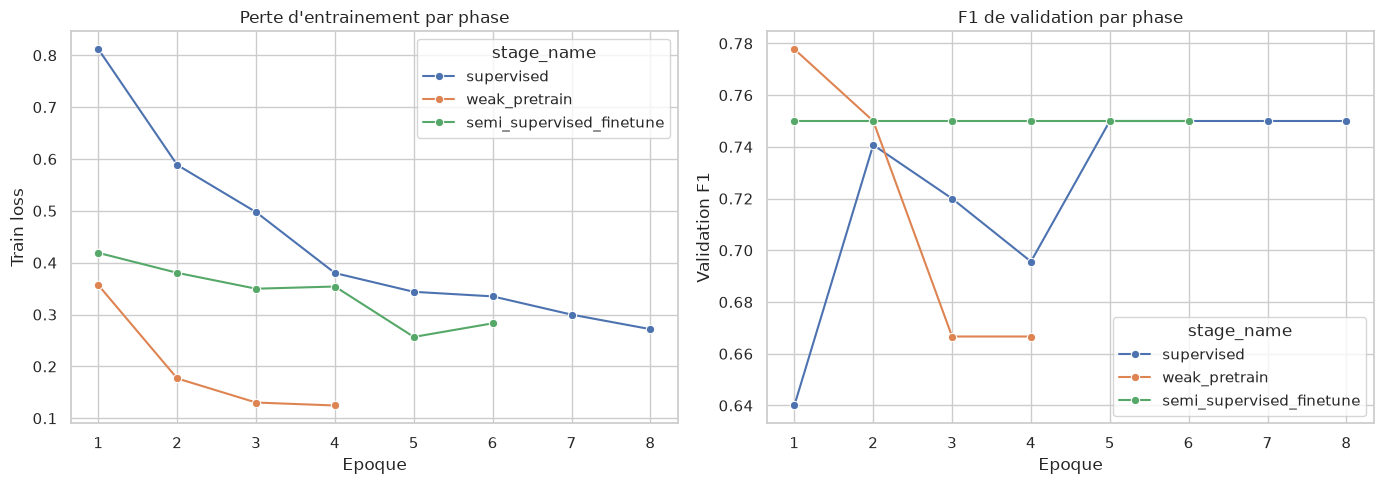

In [13]:
history_comparison_df = pd.concat(
    [supervised_history_df, weak_pretrain_history_df, semi_finetune_history_df],
    ignore_index=True,
)

fig = plot_training_history(history_comparison_df)
save_figure(fig, "04_semi_supervised_training_histories")
plt.show()


Figure sauvegardée : /home/maxime/projects/brainscan-semisupervised/reports/figures/semi_supervised/04_semi_supervised_confusion_matrices.png


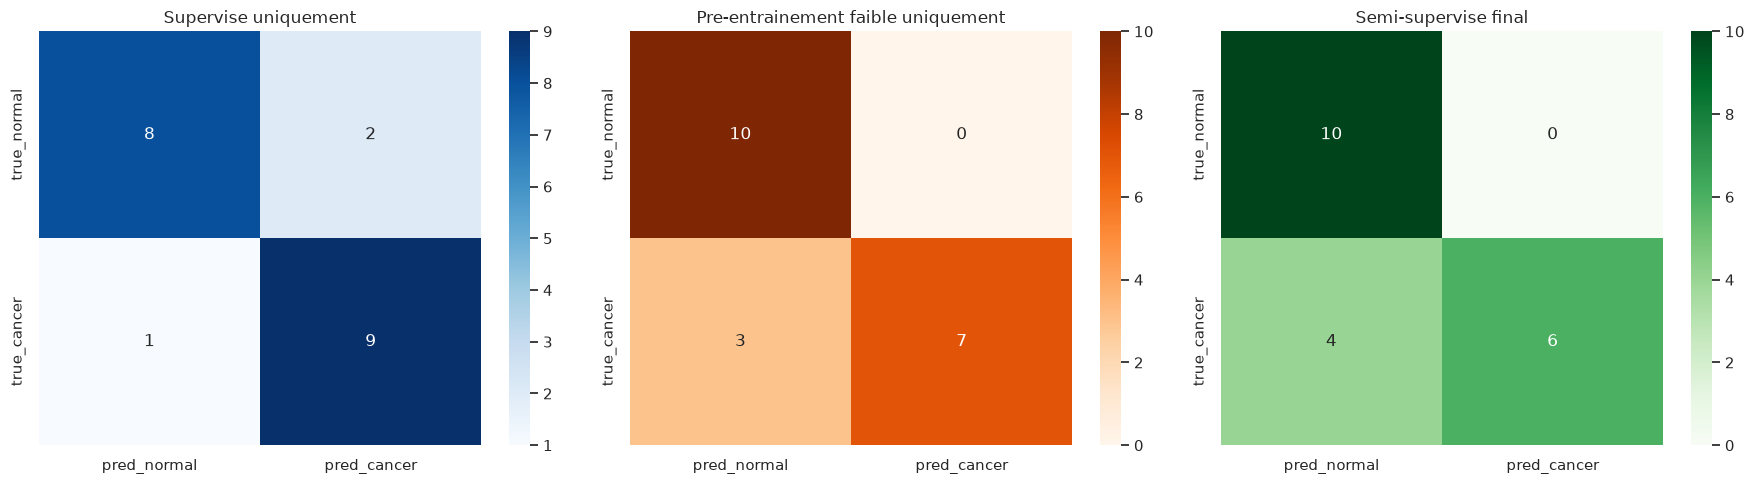

In [15]:
supervised_confusion_df = build_confusion_table(supervised_test_predictions_df)
weak_only_confusion_df = build_confusion_table(weak_only_test_predictions_df)
semi_supervised_confusion_df = build_confusion_table(semi_supervised_test_predictions_df)

fig = plot_confusion_matrices(
    [
        (supervised_confusion_df, "Supervise uniquement", "Blues"),
        (weak_only_confusion_df, "Pre-entrainement faible uniquement", "Oranges"),
        (semi_supervised_confusion_df, "Semi-supervise final", "Greens"),
    ]
)

save_figure(fig, "04_semi_supervised_confusion_matrices")
plt.show()

# display(supervised_confusion_df)
# display(weak_only_confusion_df)
# display(semi_supervised_confusion_df)


## 7. Export des artefacts

On sauvegarde les métriques, l'historique et les prédictions du jeu de test pour documenter proprement la comparaison.

In [16]:
comparison_path = OUTPUT_DIR / "semi_supervised_experiment_comparison.csv"
history_path = OUTPUT_DIR / "semi_supervised_training_history.csv"
predictions_path = OUTPUT_DIR / "semi_supervised_test_predictions.csv"
split_manifest_path = OUTPUT_DIR / "semi_supervised_split_manifest.csv"
run_config_path = OUTPUT_DIR / "semi_supervised_run_config.json"

combined_test_predictions_df = combine_test_predictions(
    [
        ("supervised_only", supervised_test_predictions_df),
        ("weak_pretrain_only", weak_only_test_predictions_df),
        ("semi_supervised_final", semi_supervised_test_predictions_df),
    ]
)

run_config = {
    "random_seed": RANDOM_SEED,
    "device": str(DEVICE),
    "strong_train_fraction": STRONG_TRAIN_FRACTION,
    "strong_validation_fraction": STRONG_VALIDATION_FRACTION,
    "strong_test_fraction": STRONG_TEST_FRACTION,
    "supervised_epochs": SUPERVISED_EPOCHS,
    "weak_pretrain_epochs": WEAK_PRETRAIN_EPOCHS,
    "semi_supervised_finetune_epochs": SEMISUPERVISED_FINETUNE_EPOCHS,
    "supervised_learning_rate": SUPERVISED_LR,
    "weak_pretrain_learning_rate": WEAK_PRETRAIN_LR,
    "semi_supervised_finetune_learning_rate": SEMISUPERVISED_FINETUNE_LR,
    "strong_train_batch_size": STRONG_TRAIN_BATCH_SIZE,
    "weak_train_batch_size": WEAK_TRAIN_BATCH_SIZE,
}

experiment_comparison_df.to_csv(comparison_path, index=False)
history_comparison_df.to_csv(history_path, index=False)
combined_test_predictions_df.to_csv(predictions_path, index=False)
split_manifest_df.to_csv(split_manifest_path, index=False)
run_config_path.write_text(json.dumps(run_config, indent=2, ensure_ascii=False))

artifact_df = pd.DataFrame(
    {
        "artifact": [
            "experiment_comparison_csv",
            "training_history_csv",
            "test_predictions_csv",
            "split_manifest_csv",
            "run_config_json",
        ],
        "path": [
            str(comparison_path),
            str(history_path),
            str(predictions_path),
            str(split_manifest_path),
            str(run_config_path),
        ],
    }
)

display(artifact_df)


,artifact,path
0,experiment_comparison_csv,/home/maxime/projects/brainscan-semisupervised...
1,training_history_csv,/home/maxime/projects/brainscan-semisupervised...
2,test_predictions_csv,/home/maxime/projects/brainscan-semisupervised...
3,split_manifest_csv,/home/maxime/projects/brainscan-semisupervised...
4,run_config_json,/home/maxime/projects/brainscan-semisupervised...


## 8. Observations et interprétation

### Résultat principal de cette exécution

Sur cette expérimentation, le modèle **semi-supervisé final** ne surpasse pas le baseline **supervisé uniquement** sur le jeu de test. Les métriques observées sont les suivantes :

- **supervisé uniquement** : `accuracy = 0,80`, `F1 = 0,80`, `precision = 0,80`, `recall = 0,80` ;
- **pré-entraînement sur labels faibles uniquement** : `accuracy = 0,85`, `F1 = 0,824`, `precision = 1,00`, `recall = 0,70` ;
- **semi-supervisé final après fine-tuning** : `accuracy = 0,80`, `F1 = 0,75`, `precision = 1,00`, `recall = 0,60`.

### Comment interpréter ces résultats

Le signal le plus intéressant est que le modèle pré-entraîné uniquement sur les labels faibles obtient déjà des performances non triviales sur le jeu de test fortement labellisé. Cela confirme que les pseudo-labels générés à l'étape 3 contiennent une information utile.

En revanche, dans cette configuration précise, le **fine-tuning sur le petit jeu fortement labellisé ne transforme pas ce signal en gain final de performance**. Au contraire, le rappel du modèle semi-supervisé final chute à `0,60`, ce qui est problématique dans un contexte de détection de tumeur, où l'on souhaite limiter au maximum les faux négatifs.

### Ce que l'on peut conclure à ce stade

- les labels faibles produits par le clustering ne sont pas inutiles ; ils apportent bien un signal exploitable ;
- en revanche, la stratégie de fine-tuning retenue ici n'est pas encore suffisante pour battre le baseline supervisé ;
- le pipeline semi-supervisé, dans sa forme actuelle, ne peut donc pas être retenu tel quel comme meilleure solution ;
- le baseline supervisé reste, pour cette expérience, la référence la plus robuste et la plus équilibrée.

### Hypothèses expliquant ce comportement

Plusieurs facteurs peuvent expliquer pourquoi le modèle semi-supervisé final n'améliore pas les performances :

- les pseudo-labels issus du clustering restent bruités ;
- le jeu fortement labellisé est très petit (`100` images), ce qui rend le fine-tuning instable ;
- le choix d'un entraînement limité à la tête de classification d'un `ResNet18` pré-entraîné peut ne pas suffire à exploiter pleinement le signal ;
- les hyperparamètres de pré-entraînement et de fine-tuning restent perfectibles.

### Décision méthodologique pour la suite

À ce stade, la conclusion raisonnable est la suivante : **la piste semi-supervisée reste intéressante, mais elle n'est pas encore validée expérimentalement dans cette version du pipeline**.

Pour aller plus loin, il serait pertinent de tester :

- un filtrage des pseudo-labels les plus incertains ;
- un autre modèle de clustering ou un autre type d'embeddings ;
- un fine-tuning plus progressif, avec dégel partiel du backbone ;
- des réglages d'entraînement plus adaptés au très faible volume de labels forts.

En l'état, pour le rapport, on peut donc dire que **le semi-supervisé est faisable techniquement, mais que son bénéfice n'est pas encore démontré sur ce dataset avec cette implémentation**.